In [6]:
countrycode_file_path= r"C:\修論研究\VWT_historical_data\country_list.xlsx"
import pandas as pd
countrycode_df = pd.read_excel(countrycode_file_path)
countrycode_df.head()


,Country name,FAO code,Position,Reporting,Discontinuities,ISO3
0,Afghanistan,2,1,1,NaN,AFG
1,Albania,3,2,1,NaN,ALB
2,Algeria,4,3,1,NaN,DZA
3,American Samoa,5,4,0,NaN,ASM
4,Andorra,6,5,0,NaN,AND


VWTmat shape: (255, 255)
Japan index: 114 (name_col=Country name)
len(japan_exports): 255

Top destinations (iso3, export):
    iso3       export
35   BFA  12604126.00
154  MOZ  10688471.00
58   CIV   9127744.00
55   COD   4737153.40
142  MRT   4659475.50
128  LBR   3887477.30
97   GIN   3389144.00
46   HKG   2894395.90
203  SGP   2186930.00
196  STP   2124787.80
223  TGO   1879803.80
164  NER   1548776.70
41   CPV   1141266.80
12   AUS    926158.89
49   TWN    887917.49
39   CAN    688345.19
48   CHN    679979.88
23   BEN    646518.66
237  USA    566450.73
198  SEN    298760.93
world iso key: SOV_A3


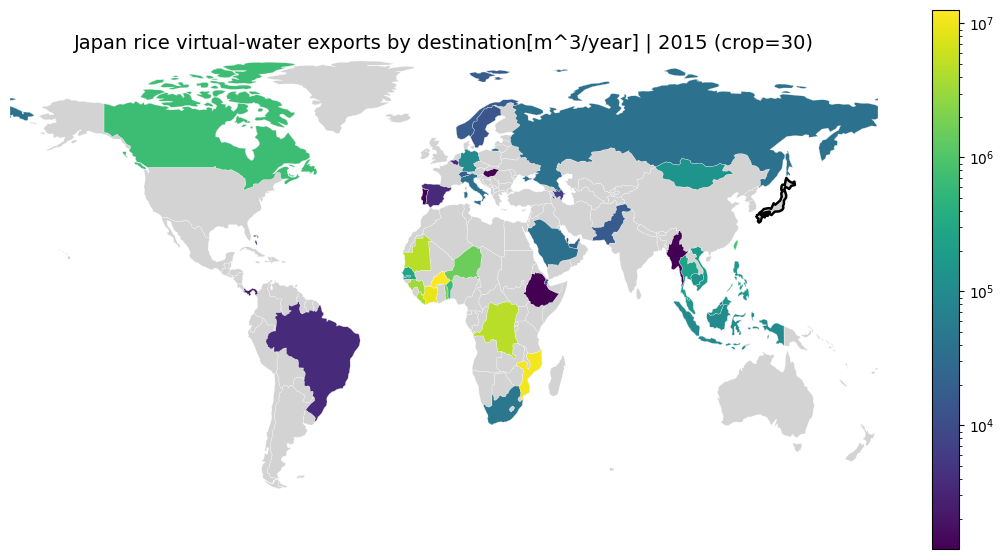

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# =========================
# SETTINGS
# =========================
year = 2015
crop = 30

# VWT country master (国名・ISO3などが入ってる想定)
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"

# VWT matrix npy
VWT_NPY = rf"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"

# Natural Earth countries shapefile in zip (あなたの環境で読める形式のまま)
NE_COUNTRIES_SHP = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

# map extent (Antarctica cut)
XLIM = (-180, 180)
YLIM = (-60, 85)

TOP_N_PRINT = 20
USE_LOG = True

# =========================
# 1) LOAD VWT MATRIX
# =========================
VWTmat = np.load(VWT_NPY).astype(float)

# 国数
N = VWTmat.shape[0]
if VWTmat.shape[0] != VWTmat.shape[1]:
    print(f"[WARN] VWTmat is not square: {VWTmat.shape}. (row=exporter, col=importer 前提を要確認)")

print("VWTmat shape:", VWTmat.shape)

# =========================
# 2) LOAD COUNTRY LIST (VWTの国順に並んでいる前提)
# =========================
cl = pd.read_excel(COUNTRY_LIST_XLSX)

# --- ISO3列を自動検出 ---
iso3_col = None
for c in cl.columns:
    if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
        iso3_col = c
        break
if iso3_col is None:
    for c in cl.columns:
        if "iso3" in str(c).strip().lower():
            iso3_col = c
            break
if iso3_col is None:
    raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

# --- 国名列（Japan を探す列）を推定 ---
# まず "Japan" が入ってそうな列を探索。ダメなら1列目を使う。
name_col = None
for c in cl.columns:
    # 文字列化して "Japan" が含まれるかチェック（NaNは除外）
    s = cl[c].dropna().astype(str)
    if (s == "Japan").any():
        name_col = c
        break
if name_col is None:
    name_col = cl.columns[0]  # 最後の手段：1列目が国名の前提

# VWTの国数Nに合わせて切る（country_listがVWT順であることが重要）
clN = cl.iloc[:N].copy()

# Japan index を country_list から取得（countrycode_df 不要）
hit = clN[clN[name_col].astype(str) == "Japan"]
if len(hit) == 0:
    # "Japan" という表記揺れの可能性がある場合の救済（例: "Japan "）
    hit = clN[clN[name_col].astype(str).str.strip() == "Japan"]

if len(hit) == 0:
    raise ValueError(
        f"country_list の列 '{name_col}' に 'Japan' が見つからない。"
        f"（列名候補を確認して。columns={list(cl.columns)}）"
    )

japan_index = int(hit.index[0])
print("Japan index:", japan_index, f"(name_col={name_col})")

# =========================
# 3) GET JAPAN EXPORT VECTOR
#   行=輸出国、列=輸入国 前提で「日本の行」
# =========================
japan_exports = VWTmat[japan_index, :].astype(float)
print("len(japan_exports):", len(japan_exports))

# =========================
# 4) BUILD dest (iso3 + export)
# =========================
dest = clN[[iso3_col]].rename(columns={iso3_col: "iso3"}).copy()
dest["iso3"] = dest["iso3"].astype(str).str.strip()

if len(dest) != len(japan_exports):
    raise ValueError(f"長さが合わない: len(dest)={len(dest)} vs len(japan_exports)={len(japan_exports)}")

dest["export"] = japan_exports

# 上位輸出先（向き・国順の確認用）
dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)
print("\nTop destinations (iso3, export):")
print(dest_pos.head(TOP_N_PRINT))

# =========================
# 5) LOAD WORLD MAP (Natural Earth shp)
# =========================
world = gpd.read_file(NE_COUNTRIES_SHP)

# ISO3列（world側）を自動検出
world_iso_candidates = ["SOV_A3", "ISO_A3", "ADM0_A3", "iso_a3", "ISO3", "ISO"]
world_iso_key = next((c for c in world_iso_candidates if c in world.columns), None)
if world_iso_key is None:
    raise ValueError(f"world にISO3列が見つからない。columns={list(world.columns)}")

world[world_iso_key] = world[world_iso_key].astype(str).str.strip()
print("world iso key:", world_iso_key)

# =========================
# 6) MERGE (地図に輸出量を貼り付ける)
# =========================
m = world.merge(
    dest[["iso3", "export"]],
    left_on=world_iso_key,
    right_on="iso3",
    how="left"
)

# =========================
# 7) PLOT
# =========================
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_axis_off()
ax.set_title(f"Japan rice virtual-water exports by destination[m^3/year] | {year} (crop={crop})", fontsize=14)

# ベース：輸出なし・欠損は薄灰
m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

# 正の輸出だけ着色
pos = m["export"].fillna(0) > 0
if pos.any():
    if USE_LOG:
        vmin = m.loc[pos, "export"].min()
        vmax = m.loc[pos, "export"].max()
        m.loc[pos].plot(
            ax=ax,
            column="export",
            norm=LogNorm(vmin=vmin, vmax=vmax),
            linewidth=0.2,
            edgecolor="white",
            legend=True,
        )
    else:
        m.loc[pos].plot(
            ax=ax,
            column="export",
            linewidth=0.2,
            edgecolor="white",
            legend=True,
        )
else:
    print("[WARN] export > 0 が1つも無い（向きが逆、year/cropが違う、Japan indexが違う等を疑う）")

# 日本を枠で強調（world側ISO列でJPNを探す）
jpn = m[m[world_iso_key] == "JPN"]
if len(jpn) > 0:
    jpn.boundary.plot(ax=ax, linewidth=1.8, color="black")
else:
    print("[WARN] world側で JPN が見つからない（ISO列キーの問題の可能性）")

# 南極“を消す”ではなく表示範囲を切る
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)

plt.show()

# 一般化

VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_2015.npy
Exporter index: 237 (iso3=USA)

Top destinations (iso3, export):
    iso3        export
114  JPN  4.975250e+09
145  MEX  4.759600e+09
179  PHL  3.633319e+09
165  NGA  3.415318e+09
121  KOR  2.021412e+09
49   TWN  1.885487e+09
112  ITA  1.441948e+09
221  THA  1.357046e+09
52   COL  1.220716e+09
48   CHN  9.865545e+08
96   GTM  9.842641e+08
30   BRA  7.929973e+08
107  IDN  7.699984e+08
249  YEM  6.993568e+08
178  PER  6.756010e+08
67   DOM  6.412312e+08
69   EGY  6.371736e+08
68   ECU  5.854661e+08
244  VEN  4.935712e+08
245  VNM  4.894525e+08
world iso key: SOV_A3
[WARN] exporter が地図側で見つからない（ISO列の不一致の可能性）


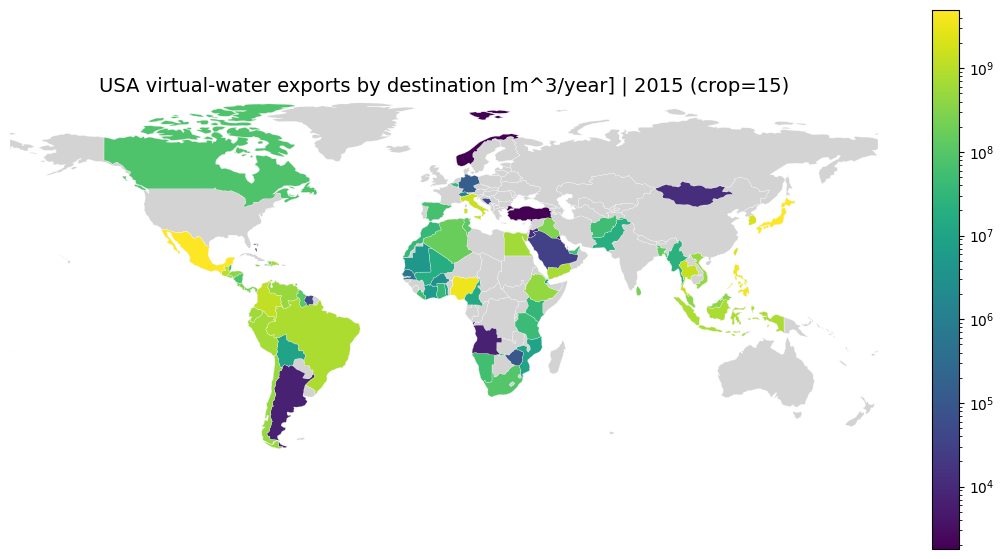

In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_vwt_exports_by_destination(
    exporter_iso3: str,
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,   # 例: r"...\VWT_npy\VWT_{crop}_{year}.npy"
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    use_log=True,
    top_n_print=20,
    unit="m^3/year",
):
    """
    VWTmat: row=exporter, col=importer 前提。
    country_list.xlsx は VWTmat の国順と一致している前提。
    country_list.xlsx には ISO3 列と（できれば）国名列がある想定。
    """

    exporter_iso3 = str(exporter_iso3).strip().upper()

    # -------------------------
    # 1) Load VWT matrix
    # -------------------------
    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    VWTmat = np.load(vwt_path).astype(float)

    N = VWTmat.shape[0]
    if VWTmat.shape[0] != VWTmat.shape[1]:
        print(f"[WARN] VWTmat is not square: {VWTmat.shape}. row/colの向きを要確認")

    print("VWTmat shape:", VWTmat.shape)
    print("VWT file:", vwt_path)

    # -------------------------
    # 2) Load country list
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    # ISO3列を自動検出
    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    # exporter index を ISO3で決める（国名に依存しない）
    hit = clN.index[clN["_iso3"] == exporter_iso3]
    if len(hit) == 0:
        raise ValueError(
            f"exporter_iso3={exporter_iso3} が country_list の先頭N行に見つからない。\n"
            f"・country_listがVWT順になっているか\n"
            f"・ISO3列の中身が正しいか\n"
            f"・exporter_iso3の表記(JPNなど)が正しいか を確認して。"
        )
    exporter_index = int(hit[0])
    print("Exporter index:", exporter_index, f"(iso3={exporter_iso3})")

    # -------------------------
    # 3) Export vector (destinations)
    # -------------------------
    exports = VWTmat[exporter_index, :].astype(float)

    dest = pd.DataFrame({"iso3": clN["_iso3"].values, "export": exports})
    dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)

    print("\nTop destinations (iso3, export):")
    print(dest_pos.head(top_n_print))

    # -------------------------
    # 4) Load world map
    # -------------------------
    world = gpd.read_file(ne_countries_shp)

    world_iso_candidates = ["SOV_A3", "ISO_A3", "ADM0_A3", "iso_a3", "ISO3", "ISO"]
    world_iso_key = next((c for c in world_iso_candidates if c in world.columns), None)
    if world_iso_key is None:
        raise ValueError(f"world にISO3列が見つからない。columns={list(world.columns)}")

    world["_iso3"] = world[world_iso_key].astype(str).str.strip().str.upper()
    print("world iso key:", world_iso_key)

    # -------------------------
    # 5) Merge
    # -------------------------
    m = world.merge(dest, left_on="_iso3", right_on="iso3", how="left")

    # -------------------------
    # 6) Plot
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(
        f"{exporter_iso3} virtual-water exports by destination [{unit}] | {year} (crop={crop})",
        fontsize=14
    )

    # base
    m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

    pos = m["export"].fillna(0) > 0
    if pos.any():
        if use_log:
            vmin = m.loc[pos, "export"].min()
            vmax = m.loc[pos, "export"].max()
            m.loc[pos].plot(
                ax=ax,
                column="export",
                norm=LogNorm(vmin=vmin, vmax=vmax),
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
        else:
            m.loc[pos].plot(
                ax=ax,
                column="export",
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
    else:
        print("[WARN] export > 0 が1つも無い（向きが逆、year/cropが違う等を疑う）")

    # highlight exporter boundary
    src = m[m["_iso3"] == exporter_iso3]
    if len(src) > 0:
        src.boundary.plot(ax=ax, linewidth=1.8, color="black")
    else:
        print("[WARN] exporter が地図側で見つからない（ISO列の不一致の可能性）")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    # 便利なので返す（確認・再利用用）
    return dest_pos, m


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

dest_pos, merged_map = plot_vwt_exports_by_destination(
    exporter_iso3="USA",  # ←ここだけ変える
    year=2015,            # ←ここだけ変える
    crop=15,              # ←ここだけ変える
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    top_n_print=20,
)

# 海外領土とか無視、普通に国名で結び付け

VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_1990.npy
Exporter index: 39 (iso3=CAN)

Top destinations (iso3, export):
    iso3        export
48   CHN  5.673500e+09
241  NAN  5.527534e+09
114  JPN  2.033019e+09
108  IRN  1.257216e+09
2    DZA  8.645236e+08
237  USA  8.627266e+08
60   CUB  7.451514e+08
208  ZAF  5.927278e+08
109  IRQ  5.803220e+08
179  PHL  5.666872e+08
121  KOR  5.243574e+08
112  ITA  4.779646e+08
17   BGD  4.558210e+08
244  VEN  4.527470e+08
235  GBR  4.273579e+08
107  IDN  3.285738e+08
52   COL  3.243448e+08
21   NAN  3.117319e+08
153  MAR  1.900539e+08
49   TWN  1.861363e+08
world iso key: ISO_A3 (fixed)


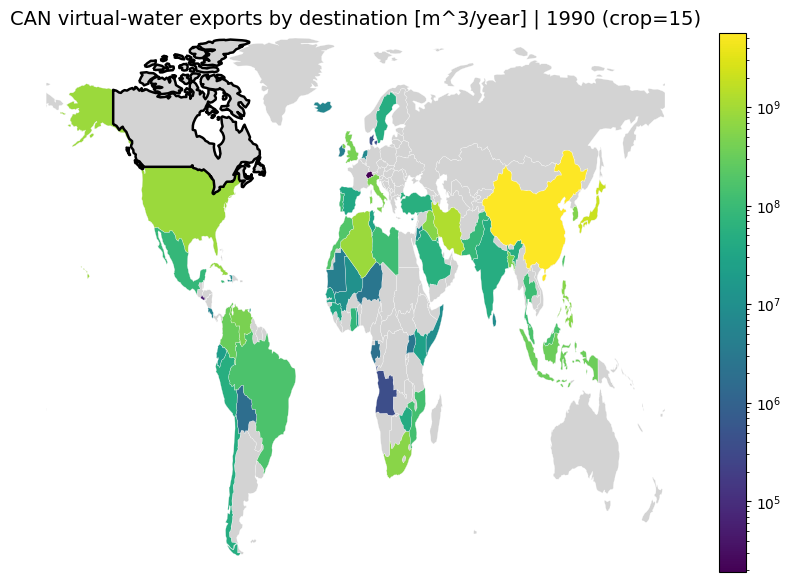

In [15]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_vwt_exports_by_destination(
    exporter_iso3: str,
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,   # 例: r"...\VWT_npy\VWT_{crop}_{year}.npy"
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    use_log=True,
    top_n_print=20,
    unit="m^3/year",
):
    """
    VWTmat: row=exporter, col=importer 前提。
    country_list.xlsx は VWTmat の国順と一致している前提。
    world map は Natural Earth の ISO_A3（=普通のISO3）で結合する。
    """

    exporter_iso3 = str(exporter_iso3).strip().upper()

    # -------------------------
    # 1) Load VWT matrix
    # -------------------------
    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    VWTmat = np.load(vwt_path).astype(float)

    N = VWTmat.shape[0]
    if VWTmat.shape[0] != VWTmat.shape[1]:
        print(f"[WARN] VWTmat is not square: {VWTmat.shape}. row/colの向きを要確認")

    print("VWTmat shape:", VWTmat.shape)
    print("VWT file:", vwt_path)

    # -------------------------
    # 2) Load country list
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    # ISO3列を自動検出（country_list側）
    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    # exporter index を ISO3で決める
    hit = clN.index[clN["_iso3"] == exporter_iso3]
    if len(hit) == 0:
        raise ValueError(
            f"exporter_iso3={exporter_iso3} が country_list の先頭N行に見つからない。\n"
            f"・country_listがVWT順になっているか\n"
            f"・ISO3列の中身が正しいか\n"
            f"・exporter_iso3の表記(USA/JPNなど)が正しいか を確認して。"
        )
    exporter_index = int(hit[0])
    print("Exporter index:", exporter_index, f"(iso3={exporter_iso3})")

    # -------------------------
    # 3) Export vector (destinations)
    # -------------------------
    exports = VWTmat[exporter_index, :].astype(float)

    dest = pd.DataFrame({"iso3": clN["_iso3"].values, "export": exports})
    dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)

    print("\nTop destinations (iso3, export):")
    print(dest_pos.head(top_n_print))

    # -------------------------
    # 4) Load world map (ISO_A3 固定)
    # -------------------------
    world = gpd.read_file(ne_countries_shp)

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    # Natural Earth の ISO_A3 は -99 が混ざることがある（=ISO不明/特殊）
    world["_iso3"] = world["ISO_A3"].astype(str).str.strip().str.upper()
    world.loc[world["_iso3"].isin(["-99", "NAN", "NONE", ""]), "_iso3"] = np.nan

    print("world iso key: ISO_A3 (fixed)")

    # -------------------------
    # 5) Merge
    # -------------------------
    m = world.merge(dest, left_on="_iso3", right_on="iso3", how="left")

    # -------------------------
    # 6) Plot
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(
        f"{exporter_iso3} virtual-water exports by destination [{unit}] | {year} (crop={crop})",
        fontsize=14
    )

    # base
    m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

    pos = m["export"].fillna(0) > 0
    if pos.any():
        if use_log:
            vmin = m.loc[pos, "export"].min()
            vmax = m.loc[pos, "export"].max()
            m.loc[pos].plot(
                ax=ax,
                column="export",
                norm=LogNorm(vmin=vmin, vmax=vmax),
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
        else:
            m.loc[pos].plot(
                ax=ax,
                column="export",
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
    else:
        print("[WARN] export > 0 が1つも無い（向きが逆、year/cropが違う等を疑う）")

    # highlight exporter boundary (ISO3同士なので基本ヒットする)
    src = m[m["_iso3"] == exporter_iso3]
    if len(src) > 0:
        src.boundary.plot(ax=ax, linewidth=1.8, color="black")
    else:
        print("[WARN] exporter が地図側で見つからない（ISO_A3にその国が無い/特殊コードの可能性）")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return dest_pos, m


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

dest_pos, merged_map = plot_vwt_exports_by_destination(
    exporter_iso3="CAN",
    year=1990,
    crop=15,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    top_n_print=20,
)

# 対数軸に対するカラーバーはどの国に関しても同じものを使いたいが、、